# PGD Attacks and Defenses on a model trained on the CIFAR-10 dataset

## Notebook Overview

### 1. Training a model on the CIFAR-10 dataset

### 2. Implement Targeted and Untargeted PGD Attack on the model

### 3. Perform Adversarial training as a defense



---

### Task 2 - Defenses

#### Part a)
Perform adversarial training using PGD attack

- Get accuracy scores of untargeted and targeted PGD attacks on the adversarial trained model
-  Get accuracy scores of untargeted and targeted PGD attack executed on a cleanly trained model
- Use epsilon = 0.3
- Plot accuracies from cleanly trained model and aversarial trained model from clean test images, and adverserial images all in one plot.
- Explain the results. Comment on how effective the defense is against each attack.

#### Part b)
Implement and execute pruning defense.
- Use your own cleanly trained model (clean train data with no adverserial images)
- Use the untargeted PGD for the attack
- Use the last convolutional layer of the CNN.
- Collect the output for clean and adversarial images.
- Compute Euclidean distances and plot them. Then prune channels based on the plots.
- Plot accuracies for clean and adversarial image in pruning and no-pruning models. Plot all results in one plot.
- Discuss the results. Discuss your choice of channels picked to be pruned.

#### Part c)
Answer questions

- If you as a developer should implement a defense, but you can only
change the input to your model, what kind of defense would you apply and
why? Name one defense and explain how it works and why then this fits this
requirement (of only changing the input).


In [ ]:
# Import required packages

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm
import random

#PyTorch Specific libraries

import torch
from torch import nn, optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

In [ ]:
# Use CUDA for faster training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
# Use this method to be able to reproduce results over multiple tries
def setup_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)  # Numpy module.
    random.seed(seed)  # Python random module.
    # GPU operations have a separate seed we also want to set
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Additionally, some operations on a GPU are implemented stochastic for efficiency
        # We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

setup_seed(42)

## 1. Training a model on the CIFAR-10 dataset

- Load the CIFAR-10 train and test sets
- Train a Neural Network
  - choose an architecture, loss function, optimizer and hyperparameters
  - train the model
  - test performance using the CIFAR-10 test set

In [ ]:
# Load the CIFAR-10 train and test sets. Assert that it has loaded correctly
train_set = torchvision.datasets.CIFAR10(root='./data', transform=transforms.Compose([transforms.ToTensor()]), download=True, train=True)
assert type(train_set) ==  datasets.CIFAR10
assert len(train_set) == 50000

test_set = torchvision.datasets.CIFAR10(root='./data', transform=transforms.Compose([transforms.ToTensor()]), download=True, train=False)
assert type(test_set) == datasets.CIFAR10
assert len(test_set) == 10000

# Create a validation set
train_set, val_set = torch.utils.data.random_split(train_set, [40000, 10000])

# Create a DataLoader to wrap around the dataset - helps with batching, shuffling, parallelism and other tasks
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 77.2MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
# Examine and understand the data
print("Train set size:", len(train_set))
print("Validation set size:", len(val_set))
print("Test set size:", len(test_set))

# Get a single sample from the training set
sample_img, sample_label = train_set[39999]
print("\nImage shape:", sample_img.shape)
print("Raw Tensor:", sample_img)
classes = ['airplaine', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("Label:", classes[sample_label])

Train set size: 40000
Validation set size: 10000
Test set size: 10000

Image shape: torch.Size([3, 32, 32])
Raw Tensor: tensor([[[0.5765, 0.5922, 0.5059,  ..., 0.4549, 0.4706, 0.6039],
         [0.5922, 0.6118, 0.5686,  ..., 0.5098, 0.4706, 0.4510],
         [0.5843, 0.5451, 0.5098,  ..., 0.4471, 0.4235, 0.4745],
         ...,
         [0.2627, 0.2784, 0.3333,  ..., 0.3804, 0.3490, 0.3333],
         [0.2667, 0.2863, 0.3216,  ..., 0.3176, 0.3098, 0.3216],
         [0.2627, 0.2706, 0.2784,  ..., 0.2902, 0.2902, 0.2941]],

        [[0.5647, 0.5843, 0.4824,  ..., 0.4667, 0.4784, 0.6510],
         [0.5608, 0.5882, 0.5451,  ..., 0.5333, 0.4863, 0.4706],
         [0.5725, 0.5333, 0.4706,  ..., 0.4275, 0.4314, 0.4902],
         ...,
         [0.2627, 0.2784, 0.3294,  ..., 0.3412, 0.3294, 0.3294],
         [0.2667, 0.2863, 0.3255,  ..., 0.3098, 0.3098, 0.3216],
         [0.2667, 0.2745, 0.2863,  ..., 0.2902, 0.2902, 0.2902]],

        [[0.5765, 0.6000, 0.4980,  ..., 0.4549, 0.4667, 0.6667],
   

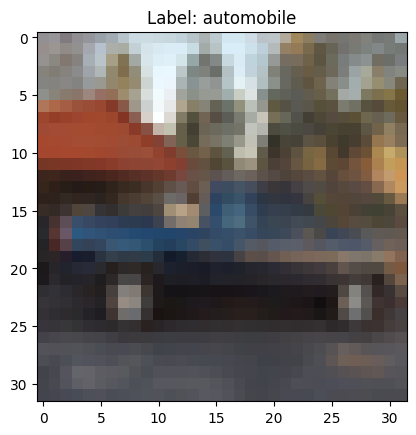

In [ ]:
# Display sample image
# Convert tensor to numpy array, then transpose. Pytorch tensor is (Channels, Height, Width), while MatPlotLib expects (Height, Width, Channels)
np_img = sample_img.numpy().transpose(1, 2, 0)
plt.imshow(np_img)
plt.title(f"Label: {classes[sample_label]}")
plt.show()

In [ ]:
# Get one batch from the DataLoader
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)

Batch image shape: torch.Size([128, 3, 32, 32])


Train a Neural Network

In [ ]:
# Define model architecture

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Feature extraction part with three convolutional blocks.
        self.features = nn.Sequential(
            # Block 1: Two 3x3 convolutions -> BN -> ReLU, then max pooling
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32 -> 16x16
            nn.Dropout(0.25),

            # Block 2: Increase channels, similar structure
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16 -> 8x8
            nn.Dropout(0.25),

            # Block 3: Further increase channels and extract more complex features
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8x8 -> 4x4
            nn.Dropout(0.25)
        )

        # Classifier part
        self.classifier = nn.Sequential(
            nn.Flatten(),  # Flatten feature maps: 256 channels * 4 * 4 = 4096 features
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)  # Final layer for 10 classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def set_record(self,record):
        self.record=record

    def get_record(self):
        return self.record

    def set_mask(self,layer,mask):
        self.mask[layer] = mask

    def get_mask(self,layer):
        return self.mask[layer]

    def record_layer(self,layer: str,record: bool):
        self.record_layer[layer] = record

    def prune_layer(self,layer: str,prune: bool):
        self.prune_layer[layer] = prune

In [ ]:
# Method to compute accuracy
def accuracy(outputs,labels):
    _, preds = torch.max(outputs, dim=1)
    return (torch.tensor(torch.sum(preds == labels).item() / len(preds)))

Define loss function, optimizer, hyperparameters. Then train model.

In [ ]:
def train_model(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):
    """
    Train and validate a given model.

    Parameters:
        model (torch.nn.Module): The model to train.
        train_loader (DataLoader): Dataloader for training data.
        val_loader (DataLoader): Dataloader for validation data.
        loss_function (torch.nn.Module): Loss function to use.
        optimizer (torch.optim.Optimizer): Optimizer for training.
        num_epochs (int): Number of epochs to train for.
        device (torch.device): Device to run training on (CPU/GPU).

    Returns:
        tuple: Lists of validation loss and accuracy over epochs.
    """
    model.to(device)

    val_loss = []
    val_acc = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Training Phase
        model.train()
        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()  # Reset gradients
            predictions = model(images)  # Forward pass
            loss = loss_function(predictions, labels)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights

        # Validation Phase
        model.eval()
        batch_val_losses = []
        batch_val_accs = []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device)
                predictions = model(images)
                batch_val_loss = loss_function(predictions, labels)
                batch_val_acc = accuracy(predictions, labels)

                batch_val_losses.append(batch_val_loss)
                batch_val_accs.append(batch_val_acc)

        epoch_val_loss = torch.stack(batch_val_losses).mean()
        epoch_val_acc = torch.stack(batch_val_accs).mean()
        val_loss.append(epoch_val_loss)
        val_acc.append(epoch_val_acc)

        print(f"Validation Loss: {epoch_val_loss.item():.2f}")
        print(f"Validation Accuracy: {epoch_val_acc.item()*100:.2f}%")

    final_val_loss = round(torch.stack(val_loss).mean().item(), 2)
    final_val_acc = round(torch.stack(val_acc).mean().item() * 100.0, 2)
    print(f"Final Validation Loss: {final_val_loss}")
    print(f"Final Validation Accuracy: {final_val_acc}%")

    return val_loss, val_acc  # Return loss and accuracy history

In [ ]:
model = CNN()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)
num_epochs = 10

val_loss, val_acc = train_model(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device)

Epoch 1/10


Validation: 100%|██████████| 79/79 [00:01<00:00, 40.34it/s]


Validation Loss: 1.75
Validation Accuracy: 30.70%
Epoch 2/10


Validation: 100%|██████████| 79/79 [00:01<00:00, 40.07it/s]


Validation Loss: 1.44
Validation Accuracy: 46.27%
Epoch 3/10


...

Validation Loss: 0.84
Validation Accuracy: 70.29%
Epoch 9/10


Validation: 100%|██████████| 79/79 [00:02<00:00, 36.42it/s]


Validation Loss: 0.80
Validation Accuracy: 71.96%
Epoch 10/10


Validation: 100%|██████████| 79/79 [00:03<00:00, 23.56it/s]

Validation Loss: 0.78
Validation Accuracy: 72.95%
Final Validation Loss: 1.11
Final Validation Accuracy: 59.61%


In [ ]:
model = CNN().to(device)
model.load_state_dict(torch.load("cnn_model.pth"))
model.eval()

<ipython-input-42-e9ca04aedc0c>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("cnn_model.pth"))


CNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, c

In [ ]:
def evaluate_model(model, test_loader, loss_function, device):
    """
    Evaluates the model on a given test dataset.

    Parameters:
        model (torch.nn.Module): The trained model to evaluate.
        test_loader (DataLoader): DataLoader for the test dataset.
        loss_function (torch.nn.Module): Loss function used for evaluation.
        device (str): Device to run the model on ("cuda" or "cpu").

    Returns:
        tuple: (average test loss, average test accuracy)
    """
    test_loss = []
    test_acc = []

    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        for batch in tqdm(test_loader):
            # Prepare batch data
            images, labels = batch
            images, labels = images.to(device), labels.to(device)

            # Generate predictions
            predictions = model(images)

            # Calculate loss
            loss = loss_function(predictions, labels)

            # Calculate accuracy
            acc = accuracy(predictions, labels)  # Ensure you have an 'accuracy' function defined

            # Store batch results
            test_loss.append(loss)
            test_acc.append(acc)

    # Compute average loss and accuracy
    avg_test_loss = torch.stack(test_loss).mean().item()
    avg_test_acc = torch.stack(test_acc).mean().item() * 100.0

    print(f"Test Loss: {round(avg_test_loss, 2)}")
    print(f"Test Accuracy: {round(avg_test_acc, 2)}%")

    return avg_test_loss, avg_test_acc

In [ ]:
test_loss, test_acc = evaluate_model(model, test_loader, loss_function, device)

100%|██████████| 79/79 [00:02<00:00, 35.51it/s]

Test Loss: 0.82
Test Accuracy: 72.04%


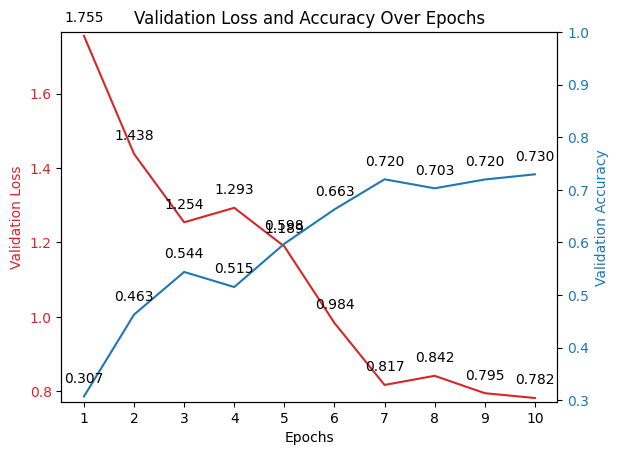

In [ ]:
# Plot Training
import matplotlib.pyplot as plt

val_losses = torch.stack(val_loss).cpu()
val_accs = torch.stack(val_acc).cpu()

epochs = range(1, len(val_losses)+1)

fig, ax1 = plt.subplots()

ax1.set_xlabel('Epochs')
ax1.set_ylabel("Validation Loss", color="tab:red")
ax1.plot(epochs, val_losses, color="tab:red")
ax1.tick_params(axis='y', labelcolor="tab:red")

# Set y-axis range for validation loss
ax1.set_ylim([min(val_losses) - 0.01, max(val_losses) + 0.01])

# Annotating each point for val_loss
for i, txt in enumerate(val_losses):
    ax1.annotate(f"{txt:.3f}", (epochs[i], val_losses[i]), textcoords="offset points", xytext=(0,10), ha='center', color='black')

ax2 = ax1.twinx()
ax2.set_ylabel('Validation Accuracy', color="tab:blue")
ax2.plot(epochs, val_accs, color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Set y-axis range for validation accuracy
ax2.set_ylim([min(val_accs) - 0.01, 1.0])

# Annotating each point for val_acc
for i, txt in enumerate(val_accs):
    ax2.annotate(f"{txt:.3f}", (epochs[i], val_accs[i]), textcoords="offset points", xytext=(0,10), ha='center', color='black')

plt.xticks(epochs)

plt.title("Validation Loss and Accuracy Over Epochs")
plt.show()

In [ ]:
# Define path to save the model
model_path = "/content/cnn_model.pth"

# Save the model's state_dict
torch.save(model.state_dict(), model_path)

print(f"Model saved to {model_path}")

Model saved to /content/cnn_model.pth


## 2. Implement the untargeted and targeted version of the PGD attack

- The class cat (class index 3) will be used as a target with epsilon values ranging from 0.0 (clean images) up to (including) 0.3 (step of 0.05).
- The accuracy scores will be calculated. The accuracy drop for each epsilon value will be plotted.

In [ ]:
class UntargetedPGD(nn.Module):
    def __init__(self, model, eps=8/255, alpha=2/255, steps=10, random_start=True, loss_fn=None, device='cuda'):
        """
        Implements the Untargeted Projected Gradient Descent (PGD) attack.

        Args:
            model (nn.Module): The target model to attack.
            eps (float): Maximum perturbation allowed (attack budget).
            alpha (float): Step size for each attack iteration.
            steps (int): Number of attack iterations.
            random_start (bool): Whether to start with a random perturbation.
            loss_fn (callable): Loss function used to maximize adversarial error.
            device (str): Device to run computations on ('cuda' or 'cpu').
        """
        super().__init__()
        self.model = model.to(device)
        self.eps = eps
        self.alpha = alpha
        self.steps = steps
        self.random_start = random_start
        self.loss_fn = loss_fn if loss_fn is not None else nn.CrossEntropyLoss()
        self.device = device

    def forward(self, images, labels):
        """
        Generates adversarial examples using PGD.

        Args:
            images (torch.Tensor): Input images to perturb.
            labels (torch.Tensor): True labels of the images.

        Returns:
            torch.Tensor: Adversarial examples.
        """
        images, labels = images.to(self.device), labels.to(self.device)
        adv_images = images.clone().detach()

        if self.random_start:
            # Initialize adversarial images with a random perturbation within [-eps, eps]
            adv_images += torch.empty_like(adv_images).uniform_(-self.eps, self.eps)
            adv_images = torch.clamp(adv_images, min=0, max=1).detach()

        for _ in range(self.steps):
            adv_images.requires_grad = True  # Enable gradient tracking

            # Forward pass: Get model predictions
            outputs = self.model(adv_images)

            # Compute adversarial loss
            loss = self.loss_fn(outputs, labels)

            # Compute gradients of loss w.r.t adversarial images
            grad = torch.autograd.grad(loss, adv_images, retain_graph=False, create_graph=False)[0]

            # Apply FGSM step: Move in the direction of the gradient
            adv_images = adv_images.detach() + self.alpha * grad.sign()

            # Project the perturbation to ensure it's within the allowed epsilon bound
            delta = torch.clamp(adv_images - images, min=-self.eps, max=self.eps)
            adv_images = torch.clamp(images + delta, min=0, max=1).detach()

        return adv_images

In [ ]:
class TargetedPGD(nn.Module):
    """
    Implements the Projected Gradient Descent (PGD) attack in a targeted manner.
    The attack attempts to perturb an image to be misclassified as a specific target class.
    """
    def __init__(self, model: nn.Module, eps: float = 8/255, alpha: float = 2/255,
                 steps: int = 10, random_start: bool = True,
                 loss_fn: nn.Module = nn.CrossEntropyLoss(), device: str = 'cuda'):
        """
        Initializes the Targeted PGD attack.

        :param model: The neural network model to attack.
        :param eps: Maximum perturbation (epsilon value).
        :param alpha: Step size for each attack iteration.
        :param steps: Number of attack iterations.
        :param random_start: Whether to start from a random perturbation.
        :param loss_fn: Loss function used for optimization.
        :param device: Device to run computations on (e.g., 'cuda' or 'cpu').
        """
        super().__init__()
        self.model = model.to(device)
        self.eps = eps
        self.alpha = alpha
        self.steps = steps
        self.random_start = random_start
        self.loss_fn = loss_fn
        self.device = device

    def forward(self, images: torch.Tensor, target_labels: torch.Tensor) -> torch.Tensor:
        """
        Generates adversarial examples targeting a specific class.

        :param images: Input images to be perturbed.
        :param target_labels: Target labels for the adversarial attack.
        :return: Adversarially perturbed images.
        """
        images = images.clone().detach().to(self.device)
        target_labels = target_labels.clone().detach().to(self.device)
        adv_images = images.clone().detach()

        if self.random_start:
            # Add a small random perturbation within [-eps, eps]
            adv_images += torch.empty_like(adv_images).uniform_(-self.eps, self.eps)
            adv_images = torch.clamp(adv_images, min=0, max=1).detach()

        for _ in range(self.steps):
            adv_images.requires_grad = True
            outputs = self.model(adv_images)

            # Compute loss encouraging misclassification towards the target label
            loss = self.loss_fn(outputs, target_labels)

            # Compute gradients
            grad = torch.autograd.grad(loss, adv_images, retain_graph=False, create_graph=False)[0]

            # Move adversarial images in the direction of reducing loss for the target label
            adv_images = adv_images.detach() - self.alpha * grad.sign()

            # Ensure perturbation remains within the epsilon constraint
            delta = torch.clamp(adv_images - images, min=-self.eps, max=self.eps)
            adv_images = torch.clamp(images + delta, min=0, max=1).detach()

        return adv_images

In [ ]:
def run_attack(model, dataloader, attack, epsilon, target_class=None):
    correct = 0
    total = 0
    print(f"Running attack with epsilon = {epsilon:.3f}")

    for i, (images, labels) in enumerate(dataloader):
        images, labels = images.to(device), labels.to(device)

        if target_class is not None:
            target_labels = torch.full_like(labels, target_class)
            adv_images = attack(images, target_labels)
        else:
            adv_images = attack(images, labels)

        outputs = model(adv_images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = correct / total
    print(f"Attack completed. Accuracy after attack: {accuracy:.4f}\n")
    return accuracy

In [ ]:
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
untargeted_accuracies = []
targeted_accuracies = []

In [ ]:
for eps in epsilons:
    untargeted_pgd = UntargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
    targeted_pgd = TargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)

    untargeted_acc = run_attack(model, test_loader, untargeted_pgd, eps)
    targeted_acc = run_attack(model, test_loader, targeted_pgd, eps, target_class=3)

    untargeted_accuracies.append(untargeted_acc)
    targeted_accuracies.append(targeted_acc)

Running attack with epsilon = 0.000
Attack completed. Accuracy after attack: 0.7208

Running attack with epsilon = 0.000
Attack completed. Accuracy after attack: 0.7208

Running attack with epsilon = 0.050
Attack completed. Accuracy after attack: 0.0001

Running attack with epsilon = 0.050
Attack completed. Accuracy after attack: 0.1390

Running attack with epsilon = 0.100
Attack completed. Accuracy after attack: 0.0000

Running attack with epsilon = 0.100
Attack completed. Accuracy after attack: 0.1232

Running attack with epsilon = 0.150
Attack completed. Accuracy after attack: 0.0000

Running attack with epsilon = 0.150
Attack completed. Accuracy after attack: 0.1128

Running attack with epsilon = 0.200
Attack completed. Accuracy after attack: 0.0000

Running attack with epsilon = 0.200
Attack completed. Accuracy after attack: 0.1114

Running attack with epsilon = 0.250
Attack completed. Accuracy after attack: 0.0000

Running attack with epsilon = 0.250
Attack completed. Accuracy af

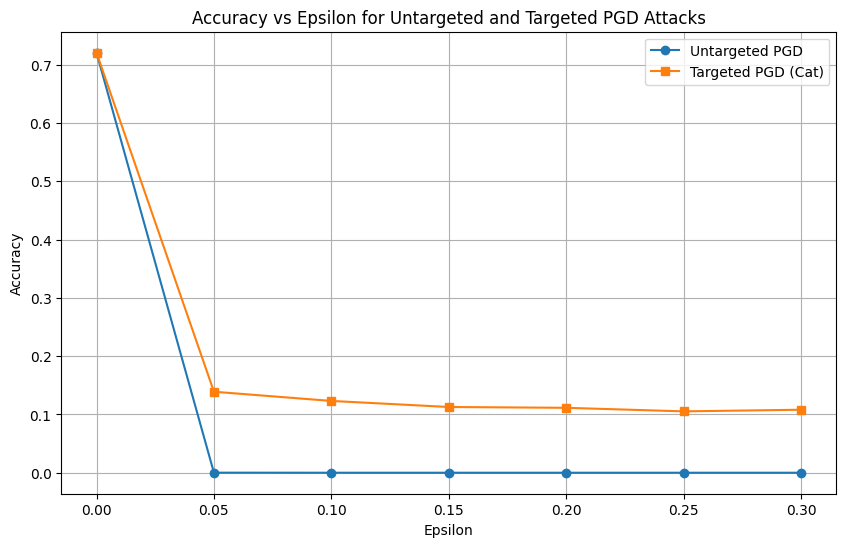

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(epsilons, untargeted_accuracies, marker='o', label='Untargeted PGD')
plt.plot(epsilons, targeted_accuracies, marker='s', label='Targeted PGD (Cat)')
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon for Untargeted and Targeted PGD Attacks')
plt.legend()
plt.grid(True)
plt.show()

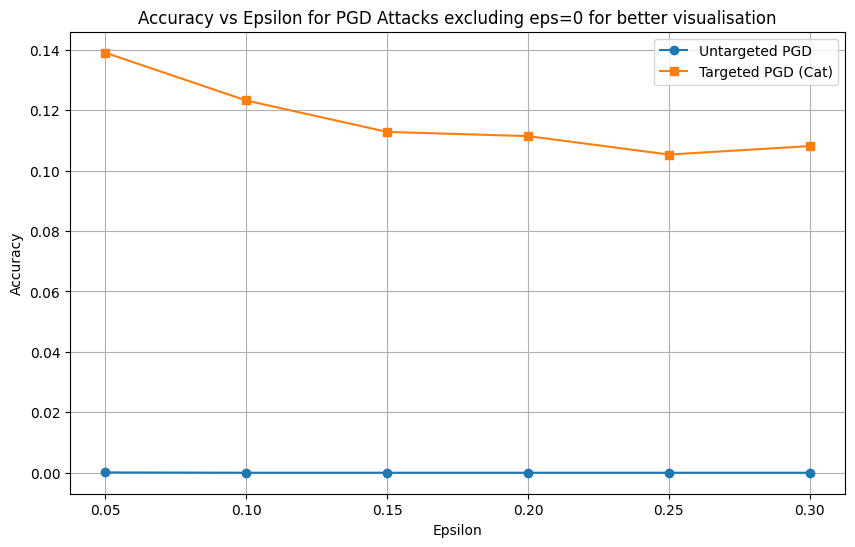

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(epsilons[1:], untargeted_accuracies[1:], marker='o', label='Untargeted PGD')
plt.plot(epsilons[1:], targeted_accuracies[1:], marker='s', label='Targeted PGD (Cat)')
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon for PGD Attacks excluding eps=0 for better visualisation')
plt.legend()
plt.grid(True)
plt.show()

Both attacks are effective, dropping the model accuracy significantly even for the smallest epsilon value tested of 0.05. This means even small perturbations results in an effective attack on the model.

The untargeted PDG attack dropped the accuracy to 0 for all epsilon values tested, even the smallest one of 0.05. This proves its effectiveness to confuse the model and skew it to make seemingly random predictions.

On the other hand, the targeted PGD attack resulted in the accuracy dropping to about 13% for epsilon=0.05 down to about 10% for epsilon=0.3 in a relatively linear fashion. This makes sense since in a targeted PDG attack the images are shifted in the direction of the chosen class, which in our case was the "cat" class. The dataset has 10 classes meaning the lowest accuracy that can be achieved with this approach would be 10%, when all the images would be classified as "cat".

## 3. Perform adversarial training using PGD attack

- Get accuracy scores of untargeted and targeted PGD attacks on the adversarial trained model
-  Get accuracy scores of untargeted and targeted PGD attack executed on a cleanly trained model
- Epsilon = 0.3 is used
- Accuracies will be plotted from cleanly trained model and aversarial trained model from the clean test images.

In [ ]:
from contextlib import nullcontext

def test_clean(model):
    state = "Clean"
    correct, total = 0, 0
    model.eval()

    torch.no_grad()

    print(f'\n\n[{state}/Test] Under Testing')

    for inputs, targets in tqdm(test_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs).detach()
        _, predicted = torch.max(outputs, dim=1)

        total += targets.numel()
        correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    print(f'[{state}/Test] Acc: {accuracy:.3f}%')
    return accuracy

def test_untargeted(model, attack):
    state = "Untargeted"
    correct, total = 0, 0
    model.eval()

    context_manager = nullcontext()
    with context_manager:
        print(f'\n\n[{state}/Test] Under Testing')

        for inputs, targets in tqdm(test_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            inputs = attack(inputs, targets)

            outputs = model(inputs).detach()
            _, predicted = torch.max(outputs, dim=1)

            total += targets.numel()
            correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    print(f'[{state}/Test] Acc: {accuracy:.3f}%')
    return accuracy

def test_targeted(model, attack):
    state = "Trageted"
    correct, total = 0, 0
    model.eval()

    context_manager = nullcontext()
    with context_manager:
        print(f'\n\n[{state}/Test] Under Testing')

        for inputs, targets in tqdm(test_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            # Create a tensor with the target label as 3 for all samples in the batch
            targeted_labels = torch.full_like(targets, 3)
            inputs = attack(inputs, targeted_labels)

            outputs = model(inputs).detach()
            _, predicted = torch.max(outputs, dim=1)

            total += targets.numel()
            correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    print(f'[{state}/Test] Acc: {accuracy:.3f}%')
    return accuracy

In [ ]:
def train_clean(model, criterion, optimizer, epochs=3):
    state = "Clean"

    for epoch in range(epochs):
        print(f'\n\n[{state}/Epoch] : {epoch + 1}')

        model.train()
        running_loss, correct, total = 0, 0, 0

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs.float())
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                pred = torch.max(model(inputs.float()), dim=1)[1]
                correct += pred.eq(targets).sum().item()

            total += targets.numel()
            running_loss += loss.item()

            if batch_idx % 100 == 0 and batch_idx != 0:
                print(f'[{state}/Train] Iter: {batch_idx}, Acc: {100. * correct / total:.3f}%, Loss: {running_loss / (batch_idx + 1):.3f}')

        # Evaluate after each epoch
        test_clean(model)

def train_untargeted(model, criterion, optimizer, attack, epochs=3):
    state = "Untargeted"

    for epoch in range(epochs):
        print(f'\n\n[{state}/Epoch] : {epoch + 1}')

        model.train()
        running_loss, correct, total = 0, 0, 0

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            inputs = attack(inputs, targets)

            optimizer.zero_grad()
            outputs = model(inputs.float())
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                pred = torch.max(model(inputs.float()), dim=1)[1]
                correct += pred.eq(targets).sum().item()

            total += targets.numel()
            running_loss += loss.item()

            if batch_idx % 100 == 0 and batch_idx != 0:
                print(f'[{state}/Train] Iter: {batch_idx}, Acc: {100. * correct / total:.3f}%, Loss: {running_loss / (batch_idx + 1):.3f}')

        # Evaluate after each epoch
        test_clean(model)

def train_targeted(model, criterion, optimizer, attack, epochs=3):
    state = "Targeted"

    for epoch in range(epochs):
        print(f'\n\n[{state}/Epoch] : {epoch + 1}')

        model.train()
        running_loss, correct, total = 0, 0, 0

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            # Create a tensor with the target label as 3 for all samples in the batch
            targeted_labels = torch.full_like(targets, 3)
            inputs = attack(inputs, targeted_labels)

            optimizer.zero_grad()
            outputs = model(inputs.float())
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                pred = torch.max(model(inputs.float()), dim=1)[1]
                correct += pred.eq(targets).sum().item()

            total += targets.numel()
            running_loss += loss.item()

            if batch_idx % 100 == 0 and batch_idx != 0:
                print(f'[{state}/Train] Iter: {batch_idx}, Acc: {100. * correct / total:.3f}%, Loss: {running_loss / (batch_idx + 1):.3f}')

        # Evaluate after each epoch
        test_clean(model)

#### Get accuracy scores of untargeted and targeted PGD attacks executed on a cleanly trained model


In [ ]:
model = CNN().to(device)
model.load_state_dict(torch.load("cnn_model.pth"))
model.eval()

clean_model_clean_test = test_clean(model)

eps=0.3

untargeted_pgd = UntargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
clean_model_untargeted_test = test_untargeted(model, untargeted_pgd)

targeted_pgd = TargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
clean_model_targeted_test = test_targeted(model, targeted_pgd)

print(clean_model_clean_test)
print(clean_model_untargeted_test)
print(clean_model_targeted_test)

<ipython-input-58-0753dd185591>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("cnn_model.pth"))




[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 29.31it/s]


[Clean/Test] Acc: 72.080%


[Untargeted/Test] Under Testing


100%|██████████| 79/79 [00:19<00:00,  4.04it/s]


[Untargeted/Test] Acc: 0.000%


[Trageted/Test] Under Testing


100%|██████████| 79/79 [00:18<00:00,  4.17it/s]

[Trageted/Test] Acc: 11.180%
72.08
0.0
11.18


#### Get accuracy scores of untargeted and targeted PGD attacks on the adversarial trained model

Approach 1 - Use cleanly trained model from above and train it on adverserial images.

1. Train using untargeted PGD adversarial images

In [ ]:
# Train
model = CNN().to(device)
model.load_state_dict(torch.load("cnn_model.pth"))
model.eval()

lr = 0.002
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.CrossEntropyLoss()
num_epochs = 5

eps=0.3
untargeted_pgd = UntargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
train_untargeted(model, criterion, optimizer, untargeted_pgd, epochs=num_epochs)

torch.save(model.state_dict(), "untargeted_train_over_clean_model.pth")

<ipython-input-59-1668ee9dbfd2>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("cnn_model.pth"))




[Untargeted/Epoch] : 1
[Untargeted/Train] Iter: 100, Acc: 9.398%, Loss: 3.206
[Untargeted/Train] Iter: 200, Acc: 9.764%, Loss: 2.764
[Untargeted/Train] Iter: 300, Acc: 9.917%, Loss: 2.613


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 31.69it/s]


[Clean/Test] Acc: 10.000%


[Untargeted/Epoch] : 2
[Untargeted/Train] Iter: 100, Acc: 10.203%, Loss: 2.305
[Untargeted/Train] Iter: 200, Acc: 10.180%, Loss: 2.305
[Untargeted/Train] Iter: 300, Acc: 10.099%, Loss: 2.304


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 37.50it/s]


...

[Clean/Test] Acc: 18.180%


[Untargeted/Epoch] : 4
[Untargeted/Train] Iter: 100, Acc: 10.705%, Loss: 2.304
[Untargeted/Train] Iter: 200, Acc: 10.572%, Loss: 2.303
[Untargeted/Train] Iter: 300, Acc: 10.551%, Loss: 2.303


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:01<00:00, 41.03it/s]


[Clean/Test] Acc: 22.150%


[Untargeted/Epoch] : 5
[Untargeted/Train] Iter: 100, Acc: 11.023%, Loss: 2.303
[Untargeted/Train] Iter: 200, Acc: 11.077%, Loss: 2.303
[Untargeted/Train] Iter: 300, Acc: 10.873%, Loss: 2.303


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:01<00:00, 39.67it/s]

[Clean/Test] Acc: 23.500%


In [ ]:
# Test
model = CNN().to(device)
model.load_state_dict(torch.load("untargeted_train_over_clean_model.pth"))
model.eval()

untargeted_pre_trained_model_clean_test = test_clean(model)

eps=0.3

untargeted_pgd = UntargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
untargeted_pre_trained_model_untargeted_test = test_untargeted(model, untargeted_pgd)

targeted_pgd = TargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
untargeted_pre_trained_model_targeted_test = test_targeted(model, targeted_pgd)

print(untargeted_pre_trained_model_clean_test)
print(untargeted_pre_trained_model_untargeted_test)
print(untargeted_pre_trained_model_targeted_test)

<ipython-input-60-a20b0058cf48>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("untargeted_train_over_clean_model.pth"))




[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 32.80it/s]


[Clean/Test] Acc: 23.500%


[Untargeted/Test] Under Testing


100%|██████████| 79/79 [00:18<00:00,  4.29it/s]


[Untargeted/Test] Acc: 5.670%


[Trageted/Test] Under Testing


100%|██████████| 79/79 [00:18<00:00,  4.28it/s]

[Trageted/Test] Acc: 18.240%
23.5
5.67
18.24


2. Train using targeted PGD adversarial images


In [ ]:
# Train
model = CNN().to(device)
model.load_state_dict(torch.load("cnn_model.pth"))
model.eval()

lr = 0.002
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.CrossEntropyLoss()
num_epochs = 5

eps=0.3
targeted_pgd = TargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)

train_targeted(model, criterion, optimizer, targeted_pgd, epochs=num_epochs)
torch.save(model.state_dict(), "targeted_train_over_clean_model.pth")

<ipython-input-61-52534d70e209>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("cnn_model.pth"))




[Targeted/Epoch] : 1
[Targeted/Train] Iter: 100, Acc: 14.913%, Loss: 2.323
[Targeted/Train] Iter: 200, Acc: 16.126%, Loss: 2.262
[Targeted/Train] Iter: 300, Acc: 17.019%, Loss: 2.231


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 31.76it/s]


[Clean/Test] Acc: 28.150%


[Targeted/Epoch] : 2
[Targeted/Train] Iter: 100, Acc: 19.926%, Loss: 2.151
[Targeted/Train] Iter: 200, Acc: 20.561%, Loss: 2.144
[Targeted/Train] Iter: 300, Acc: 20.738%, Loss: 2.138


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:01<00:00, 40.82it/s]


...

[Clean/Test] Acc: 28.880%


[Targeted/Epoch] : 4
[Targeted/Train] Iter: 100, Acc: 22.834%, Loss: 2.086
[Targeted/Train] Iter: 200, Acc: 22.835%, Loss: 2.092
[Targeted/Train] Iter: 300, Acc: 23.240%, Loss: 2.087


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:01<00:00, 40.90it/s]


[Clean/Test] Acc: 30.650%


[Targeted/Epoch] : 5
[Targeted/Train] Iter: 100, Acc: 24.838%, Loss: 2.070
[Targeted/Train] Iter: 200, Acc: 23.931%, Loss: 2.080
[Targeted/Train] Iter: 300, Acc: 24.354%, Loss: 2.067


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 32.07it/s]

[Clean/Test] Acc: 30.160%


In [ ]:
# Test
model = CNN().to(device)
model.load_state_dict(torch.load("targeted_train_over_clean_model.pth"))
model.eval()

targeted_pre_trained_model_clean_test = test_clean(model)

eps=0.3

untargeted_pgd = UntargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
targeted_pre_trained_model_untargeted_test = test_untargeted(model, untargeted_pgd)

targeted_pgd = TargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
targeted_pre_trained_model_targeted_test = test_targeted(model, targeted_pgd)

print(targeted_pre_trained_model_clean_test)
print(targeted_pre_trained_model_untargeted_test)
print(targeted_pre_trained_model_targeted_test)

<ipython-input-62-07dfa77786bc>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("targeted_train_over_clean_model.pth"))




[Clean/Test] Under Testing


100%|██████████| 79/79 [00:01<00:00, 40.10it/s]


[Clean/Test] Acc: 30.160%


[Untargeted/Test] Under Testing


100%|██████████| 79/79 [00:19<00:00,  4.13it/s]


[Untargeted/Test] Acc: 0.030%


[Trageted/Test] Under Testing


100%|██████████| 79/79 [00:18<00:00,  4.23it/s]

[Trageted/Test] Acc: 16.480%
30.16
0.03
16.48


Approach 2 - Initialize a new model (non pre-trained with random weights and biases) and train it on the adversarial images.

Untargeted

In [ ]:
# Train
model = CNN().to(device)
lr = 0.002
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.CrossEntropyLoss()
num_epochs = 5

eps=0.3
untargeted_pgd = UntargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
train_untargeted(model, criterion, optimizer, untargeted_pgd, epochs=num_epochs)

torch.save(model.state_dict(), "untargeted_train_over_random_model.pth")



[Untargeted/Epoch] : 1
[Untargeted/Train] Iter: 100, Acc: 9.847%, Loss: 2.606
[Untargeted/Train] Iter: 200, Acc: 9.838%, Loss: 2.455
[Untargeted/Train] Iter: 300, Acc: 9.881%, Loss: 2.404


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:01<00:00, 40.37it/s]


[Clean/Test] Acc: 10.000%


[Untargeted/Epoch] : 2
[Untargeted/Train] Iter: 100, Acc: 10.149%, Loss: 2.303
[Untargeted/Train] Iter: 200, Acc: 10.005%, Loss: 2.303
[Untargeted/Train] Iter: 300, Acc: 10.024%, Loss: 2.303


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 34.29it/s]


[Clean/Test] Acc: 10.000%


[Untargeted/Epoch] : 3
[Untargeted/Train] Iter: 100, Acc: 10.427%, Loss: 2.303
[Untargeted/Train] Iter: 200, Acc: 10.121%, Loss: 2.303
[Untargeted/Train] Iter: 300, Acc: 10.063%, Loss: 2.303


[Clean/Test] Under Testing


...

[Clean/Test] Acc: 10.000%


[Untargeted/Epoch] : 4
[Untargeted/Train] Iter: 100, Acc: 9.955%, Loss: 2.303
[Untargeted/Train] Iter: 200, Acc: 10.005%, Loss: 2.303
[Untargeted/Train] Iter: 300, Acc: 9.871%, Loss: 2.303


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 39.00it/s]


[Clean/Test] Acc: 10.000%


[Untargeted/Epoch] : 5
[Untargeted/Train] Iter: 100, Acc: 10.025%, Loss: 2.303
[Untargeted/Train] Iter: 200, Acc: 9.981%, Loss: 2.303
[Untargeted/Train] Iter: 300, Acc: 9.985%, Loss: 2.303


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 33.31it/s]

[Clean/Test] Acc: 10.000%


In [ ]:
# Test
model = CNN().to(device)
model.load_state_dict(torch.load("untargeted_train_over_random_model.pth"))
model.eval()

untargeted_new_model_clean_test = test_clean(model)

eps=0.3

untargeted_pgd = UntargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
untargeted_new_model_untargeted_test = test_untargeted(model, untargeted_pgd)

targeted_pgd = TargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
untargeted_new_model_targeted_test = test_targeted(model, targeted_pgd)

print(untargeted_new_model_clean_test)
print(untargeted_new_model_untargeted_test)
print(untargeted_new_model_targeted_test)

<ipython-input-64-7961091202c1>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("untargeted_train_over_random_model.pth"))




[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 31.89it/s]


[Clean/Test] Acc: 10.000%


[Untargeted/Test] Under Testing


100%|██████████| 79/79 [00:18<00:00,  4.21it/s]


[Untargeted/Test] Acc: 10.000%


[Trageted/Test] Under Testing


100%|██████████| 79/79 [00:18<00:00,  4.24it/s]

[Trageted/Test] Acc: 10.000%
10.0
10.0
10.0


Targeted

In [ ]:
# Train
model = CNN().to(device)
lr = 0.002
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.CrossEntropyLoss()
num_epochs = 5

eps=0.3
targeted_pgd = TargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
train_targeted(model, criterion, optimizer, targeted_pgd, epochs=num_epochs)

torch.save(model.state_dict(), "targeted_train_over_random_model.pth")



[Targeted/Epoch] : 1
[Targeted/Train] Iter: 100, Acc: 12.090%, Loss: 2.673
[Targeted/Train] Iter: 200, Acc: 13.122%, Loss: 2.463
[Targeted/Train] Iter: 300, Acc: 14.024%, Loss: 2.385


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 38.31it/s]


[Clean/Test] Acc: 18.940%


[Targeted/Epoch] : 2
[Targeted/Train] Iter: 100, Acc: 16.313%, Loss: 2.217
[Targeted/Train] Iter: 200, Acc: 16.360%, Loss: 2.216
[Targeted/Train] Iter: 300, Acc: 16.995%, Loss: 2.208


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:01<00:00, 41.86it/s]


[Clean/Test] Acc: 20.510%


[Targeted/Epoch] : 3
[Targeted/Train] Iter: 100, Acc: 18.541%, Loss: 2.173
[Targeted/Train] Iter: 200, Acc: 18.602%, Loss: 2.173
[Targeted/Train] Iter: 300, Acc: 18.924%, Loss: 2.166


[Clean/Test] Under Testing


...

[Clean/Test] Acc: 24.250%


[Targeted/Epoch] : 4
[Targeted/Train] Iter: 100, Acc: 20.390%, Loss: 2.153
[Targeted/Train] Iter: 200, Acc: 20.328%, Loss: 2.148
[Targeted/Train] Iter: 300, Acc: 20.450%, Loss: 2.149


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:02<00:00, 39.35it/s]


[Clean/Test] Acc: 24.980%


[Targeted/Epoch] : 5
[Targeted/Train] Iter: 100, Acc: 19.508%, Loss: 2.147
[Targeted/Train] Iter: 200, Acc: 20.406%, Loss: 2.136
[Targeted/Train] Iter: 300, Acc: 20.826%, Loss: 2.135


[Clean/Test] Under Testing


100%|██████████| 79/79 [00:01<00:00, 41.11it/s]

[Clean/Test] Acc: 26.710%


In [ ]:
# Test
model = CNN().to(device)
model.load_state_dict(torch.load("targeted_train_over_random_model.pth"))
model.eval()

targeted_new_model_clean_test = test_clean(model)

eps=0.3

untargeted_pgd = UntargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
targeted_new_model_untargeted_test = test_untargeted(model, untargeted_pgd)

targeted_pgd = TargetedPGD(model, eps=eps, alpha=eps/5, steps=10, device = device)
targeted_new_model_targeted_test = test_targeted(model, targeted_pgd)

print(targeted_new_model_clean_test)
print(targeted_new_model_untargeted_test)
print(targeted_new_model_targeted_test)

<ipython-input-66-8683cb94a63a>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("targeted_train_over_random_model.pth"))




[Clean/Test] Under Testing


100%|██████████| 79/79 [00:01<00:00, 41.58it/s]


[Clean/Test] Acc: 26.710%


[Untargeted/Test] Under Testing


100%|██████████| 79/79 [00:18<00:00,  4.27it/s]


[Untargeted/Test] Acc: 1.620%


[Trageted/Test] Under Testing


100%|██████████| 79/79 [00:18<00:00,  4.30it/s]

[Trageted/Test] Acc: 20.590%
26.71
1.62
20.59


Plot all accuracy (also from using clean test images, so no attack used) scores in one plot and compare results

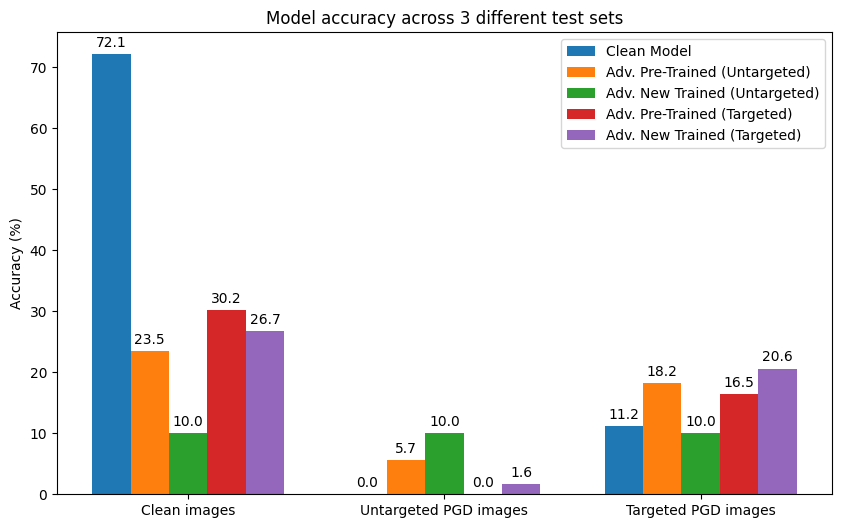

In [ ]:
clean_model_results = [clean_model_clean_test, clean_model_untargeted_test, clean_model_targeted_test]

untargeted_pre_trained_model_results = [untargeted_pre_trained_model_clean_test, untargeted_pre_trained_model_untargeted_test, untargeted_pre_trained_model_targeted_test]
targeted_pre_trained_model_results = [targeted_pre_trained_model_clean_test, targeted_pre_trained_model_untargeted_test, targeted_pre_trained_model_targeted_test]

untargeted_new_model_results = [untargeted_new_model_clean_test, untargeted_new_model_untargeted_test, untargeted_new_model_targeted_test]
targeted_new_model_results = [targeted_new_model_clean_test, targeted_new_model_untargeted_test, targeted_new_model_targeted_test]

# Data labels
models = ['Clean Model', 'Adv. Pre-Trained (Untargeted)', 'Adv. New Trained (Untargeted)', 'Adv. Pre-Trained (Targeted)', 'Adv. New Trained (Targeted)' ]
tests = ['Clean images', 'Untargeted PGD images', 'Targeted PGD images']

# Combine the data into a list of lists for easier plotting
data = np.array([clean_model_results, untargeted_pre_trained_model_results, untargeted_new_model_results, targeted_pre_trained_model_results, targeted_new_model_results])

# Set up bar chart parameters
x = np.arange(len(tests))  # the label locations for the test types
width = 0.15  # width of the bars

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - 2*width, data[0], width, label=models[0])
rects2 = ax.bar(x - width, data[1], width, label=models[1])
rects3 = ax.bar(x, data[2], width, label=models[2])
rects4 = ax.bar(x + width, data[3], width, label=models[3])
rects5 = ax.bar(x + 2*width, data[4], width, label=models[4])

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model accuracy across 3 different test sets')
ax.set_xticks(x)
ax.set_xticklabels(tests)
ax.legend()

# Optional: Add labels on top of each bar.
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
autolabel(rects5)

plt.show()

The figure above was generated using 3 accuracy tests showing how the different models performed when tested against:
- Clean image data directly from the dataset.
- Adversarial image data generated with an untargeted PGD attack using epsilon=0.3.
- Adversarial image data generated with a targeted PGD attack using epsilon=0.3 and a constant target of index 3 (cat).

5 different models are compared in the plot:
- 1 clean model trained on the clean image train data.
- 2 models trained using image data generated from an untargeted PGD attack.
  - The first model used was a pre-trained clean model from the previous exercise.
  - The second was a fresh model with randomly initialized weights and biases.
- 2 models trained using image data generated from a targeted PGD attack with target index 3 (cat).
  - One with the pre-trained model.
  - The other with a newly initialized model with random weights and biases.

The results of the clean model in blue are the same as exercise one and can be used as a baseline. There we saw an accuracy of 70% achieved by the model, where an untargeted PGD attack rendered the model useless and confused it every time, achieving 0% accuracy, white the targeted PGD attack achieved an accuracy close to 10%. While it may seem that the targetted PGD attack was not as effective as the untargetted one, this is because the target label was set to index 3 (cat) each time. This means that even for images of class "cat" were the perturbed in the direction of "cat" so the model classified them accurately. This implies the targeted attack was as effective as the untargeted one. This can be tested by changing the target label of the "cat" class during the attack. It is hypothesized that the model accuracy would also drop to zero in that case.

Now onto the adversarially trained model. Firsly, lets discuss untargeted PGD trained models. For model training a pre-trained and a newly initialized models were used. For the newly intialized model, it scored 10% accuracy, which for a 10 class dataset is as good as random. It appears that the model is not able to learn any useful information when using images with high epsilon of 0.3. We will see below that epsilon=0.3 may be too big of a perturbation.

For the pre-trained model on untargeted PGD images, the perfomance compared to the clean model dropped significantly, down to about 24%. It is sure to say that this model is not production ready. While an untargeted attack no longer resulted in a 0% accuracy but rather 5.7%, this is not a significant protection considering the large drop in accuracy to the clean images.

Finally, lets discuss the targeted PGD trained models. The pre-trained achieved the highest accuracy of around 30% when adversarially trained on targeted images. However, this did not protect it against an untargeted attack where the accuracy went straight to 0%, and it only mildly improved the targeted attack accuracy by 5.3% (from 11.2% to 16.5%). The drop in accuracy against the clean dataset does not justify the small improvement when testing against targeted PGD images.

Epsilon=0.3 may be too high for the CIFAR-10 dataset. Our simple baseline CNN model achieved around a 70% accuracy, while the MNIST dataset model in the tutorial achieved above 90%. We ran the code above for epsilon=0.1 as we believed 0.3 is too big a perturbation for adversarial training to yield any meaningful results. Due to GPU restrictions from Google Colab, the graph below was generated separately. It shows the results from running the above adversarial training with epsilon=0.1.

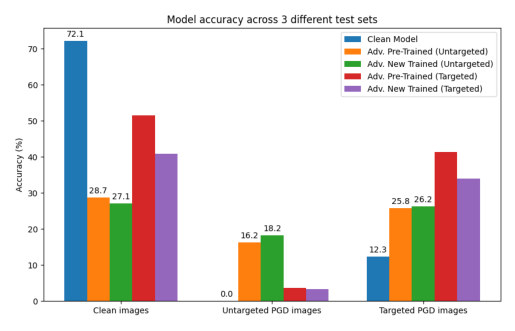

In [ ]:
import matplotlib.image as mpimg

image_path = "eps01.png"
img = mpimg.imread(image_path)

plt.imshow(img)
plt.axis('off')
plt.show()

These results are similar to the ones discussed above, the difference being that higher results were achieved. Furthermore, the untargeted PGD adversarial training no longer leads to the drop down to 10% which rendered the model useless in the scenario with epsilon=0.3.